<a href="https://colab.research.google.com/github/CodeStormSIH/krishi-kalyan/blob/main/sih_aiml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_path = "/content/SIH26032_AI_ML_Dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".zip") or file == "04_waiting_time_model_data.csv":
            print(os.path.join(root, file))

/content/SIH26032_AI_ML_Dataset.zip
/content/04_waiting_time_model_data.csv


In [ ]:
import pandas as pd
import numpy as np

# Load waiting-time dataset
file_path = "/content/04_waiting_time_model_data.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:", df.isnull().sum().sum())

print("\nFirst 5 rows:")
display(df.head())

print("\nTarget statistics:")
print(df["actual_wait_time_min"].describe())

Dataset shape: (64800, 23)

Columns:
['centre_id', 'date', 'hour', 'day_of_week', 'crop', 'weather_factor', 'current_queue', 'bookings_next_2h', 'arrivals_last_1h', 'completed_last_1h', 'active_counters', 'centre_capacity_farmers', 'hourly_capacity_farmers', 'historical_avg_queue', 'historical_avg_wait_min', 'quantity_total_kg', 'avg_quantity_per_farmer_kg', 'avg_processing_time_min', 'centre_utilization', 'arrival_service_ratio', 'hour_sin', 'hour_cos', 'actual_wait_time_min']

Missing values: 0

First 5 rows:


,centre_id,date,hour,day_of_week,crop,weather_factor,current_queue,bookings_next_2h,arrivals_last_1h,completed_last_1h,...,historical_avg_queue,historical_avg_wait_min,quantity_total_kg,avg_quantity_per_farmer_kg,avg_processing_time_min,centre_utilization,arrival_service_ratio,hour_sin,hour_cos,actual_wait_time_min
0,C001,2026-01-01,8,3,Paddy,0.97,1,5,3,3,...,8.988000,47.480792,2157,384.414804,5.150119,0.034682,1.000000,8.660254e-01,-0.500000,8.693580
1,C001,2026-01-01,9,3,Wheat,1.00,0,6,6,7,...,25.891686,60.344648,3287,542.859427,4.491501,0.034682,0.857143,7.071068e-01,-0.707107,2.251175
2,C001,2026-01-01,10,3,Maize,1.00,0,10,14,14,...,28.079856,67.632151,11434,980.598195,3.987732,0.057803,1.000000,5.000000e-01,-0.866025,2.304406
3,C001,2026-01-01,11,3,Paddy,0.88,1,14,11,11,...,33.315485,72.203746,8489,675.148399,5.685321,0.086705,1.000000,2.588190e-01,-0.965926,13.280489
4,C001,2026-01-01,12,3,Paddy,1.00,0,9,10,11,...,20.936432,59.656257,2715,255.452225,5.392361,0.052023,0.909091,1.224647e-16,-1.000000,3.860015



Target statistics:
count    64800.000000
mean        18.848185
std         27.015477
min          0.000000
25%          4.978996
50%         10.995369
75%         21.618093
max        555.963339
Name: actual_wait_time_min, dtype: float64


In [ ]:
# STEP 1B — Feature preparation + chronological split

import pandas as pd
import numpy as np

# Copy dataset
data = df.copy()

# Convert date
data["date"] = pd.to_datetime(data["date"])

# Sort chronologically
data = data.sort_values(["date", "hour"]).reset_index(drop=True)

# Target
target = "actual_wait_time_min"

# Features we will use
features = [
    "current_queue",
    "bookings_next_2h",
    "arrivals_last_1h",
    "late_arrivals_last_1h",
    "completed_last_1h",
    "active_counters",
    "centre_capacity_farmers",
    "hourly_capacity_farmers",
    "historical_avg_queue",
    "historical_avg_wait_min",
    "quantity_total_kg",
    "avg_quantity_per_farmer_kg",
    "avg_processing_time_min",
    "centre_utilization",
    "arrival_service_ratio",
    "hour_sin",
    "hour_cos",
    "weather_factor",
    "counter_disruption"
]

X = data[features]
y = data[target]

# Chronological split:
# 70% train, 15% validation, 15% test
n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("TRAIN:", X_train.shape)
print("VALIDATION:", X_val.shape)
print("TEST:", X_test.shape)

print("\nDate ranges:")
print("Train:", data["date"].iloc[0], "→", data["date"].iloc[train_end-1])
print("Validation:", data["date"].iloc[train_end], "→", data["date"].iloc[val_end-1])
print("Test:", data["date"].iloc[val_end], "→", data["date"].iloc[-1])

print("\nMissing values:")
print("Train:", X_train.isnull().sum().sum())
print("Validation:", X_val.isnull().sum().sum())
print("Test:", X_test.isnull().sum().sum())

KeyError: "['late_arrivals_last_1h', 'counter_disruption'] not in index"

In [ ]:
# STEP 1B — Inspect the actual waiting-time dataset

print("Shape:", df.shape)

print("\nActual columns in 04_waiting_time_model_data.csv:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nData types:")
print(df.dtypes)

Shape: (64800, 23)

Actual columns in 04_waiting_time_model_data.csv:
1. centre_id
2. date
3. hour
4. day_of_week
5. crop
6. weather_factor
7. current_queue
8. bookings_next_2h
9. arrivals_last_1h
10. completed_last_1h
11. active_counters
12. centre_capacity_farmers
13. hourly_capacity_farmers
14. historical_avg_queue
15. historical_avg_wait_min
16. quantity_total_kg
17. avg_quantity_per_farmer_kg
18. avg_processing_time_min
19. centre_utilization
20. arrival_service_ratio
21. hour_sin
22. hour_cos
23. actual_wait_time_min

Data types:
centre_id                      object
date                           object
hour                            int64
day_of_week                     int64
crop                           object
weather_factor                float64
current_queue                   int64
bookings_next_2h                int64
arrivals_last_1h                int64
completed_last_1h               int64
active_counters                 int64
centre_capacity_farmers         int64
ho

In [ ]:
# STEP 1C — Data quality check

import numpy as np

print("Missing values:")
print(df.isnull().sum())

print("\nInfinite values:")
numeric_cols = df.select_dtypes(include=np.number).columns
print(np.isinf(df[numeric_cols]).sum())

print("\nUnique values in categorical columns:")
print("centre_id:", df["centre_id"].nunique())
print("crop:", df["crop"].nunique())
print("crop values:", df["crop"].unique())

print("\nTarget distribution:")
print(df["actual_wait_time_min"].describe())

print("\nZero waiting-time records:",
      (df["actual_wait_time_min"] == 0).sum())

print("\nNegative waiting-time records:",
      (df["actual_wait_time_min"] < 0).sum())

Missing values:
centre_id                     0
date                          0
hour                          0
day_of_week                   0
crop                          0
weather_factor                0
current_queue                 0
bookings_next_2h              0
arrivals_last_1h              0
completed_last_1h             0
active_counters               0
centre_capacity_farmers       0
hourly_capacity_farmers       0
historical_avg_queue          0
historical_avg_wait_min       0
quantity_total_kg             0
avg_quantity_per_farmer_kg    0
avg_processing_time_min       0
centre_utilization            0
arrival_service_ratio         0
hour_sin                      0
hour_cos                      0
actual_wait_time_min          0
dtype: int64

Infinite values:
hour                          0
day_of_week                   0
weather_factor                0
current_queue                 0
bookings_next_2h              0
arrivals_last_1h              0
completed_last_1h        

In [ ]:
# ============================================================
# STEP 2A — BASIC DATASET EDA
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Rows    :", f"{df.shape[0]:,}")
print("Columns :", df.shape[1])

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

print("\n" + "=" * 60)
print("CATEGORICAL VARIABLES")
print("=" * 60)

print("Number of centres:", df["centre_id"].nunique())
print("Centre IDs:", sorted(df["centre_id"].unique()))

print("\nNumber of crops:", df["crop"].nunique())
print("Crops:", sorted(df["crop"].unique()))

print("\n" + "=" * 60)
print("DATE INFORMATION")
print("=" * 60)

date_series = pd.to_datetime(df["date"])

print("Start date:", date_series.min().date())
print("End date  :", date_series.max().date())
print("Number of days:", date_series.dt.date.nunique())

print("\n" + "=" * 60)
print("DUPLICATES")
print("=" * 60)

print("Duplicate rows:", df.duplicated().sum())

DATASET OVERVIEW
Rows    : 64,800
Columns : 23

Column names:
 1. centre_id
 2. date
 3. hour
 4. day_of_week
 5. crop
 6. weather_factor
 7. current_queue
 8. bookings_next_2h
 9. arrivals_last_1h
10. completed_last_1h
11. active_counters
12. centre_capacity_farmers
13. hourly_capacity_farmers
14. historical_avg_queue
15. historical_avg_wait_min
16. quantity_total_kg
17. avg_quantity_per_farmer_kg
18. avg_processing_time_min
19. centre_utilization
20. arrival_service_ratio
21. hour_sin
22. hour_cos
23. actual_wait_time_min

CATEGORICAL VARIABLES
Number of centres: 30
Centre IDs: ['C001', 'C002', 'C003', 'C004', 'C005', 'C006', 'C007', 'C008', 'C009', 'C010', 'C011', 'C012', 'C013', 'C014', 'C015', 'C016', 'C017', 'C018', 'C019', 'C020', 'C021', 'C022', 'C023', 'C024', 'C025', 'C026', 'C027', 'C028', 'C029', 'C030']

Number of crops: 4
Crops: ['Cotton', 'Maize', 'Paddy', 'Wheat']

DATE INFORMATION
Start date: 2026-01-01
End date  : 2026-06-29
Number of days: 180

DUPLICATES
Duplicate r

WAITING TIME ANALYSIS
Mean waiting time   : 18.85 minutes
Median waiting time : 11.00 minutes
Minimum             : 0.00 minutes
Maximum             : 555.96 minutes

Percentiles:
50th percentile     : 11.00 minutes
75th percentile     : 21.62 minutes
90th percentile     : 41.21 minutes
95th percentile     : 64.54 minutes
99th percentile     : 136.91 minutes

Waiting-time categories:
actual_wait_time_min
0–5 min      16275
5–15 min     23700
15–30 min    14594
30–60 min     6570
60+ min       3661
Name: count, dtype: int64


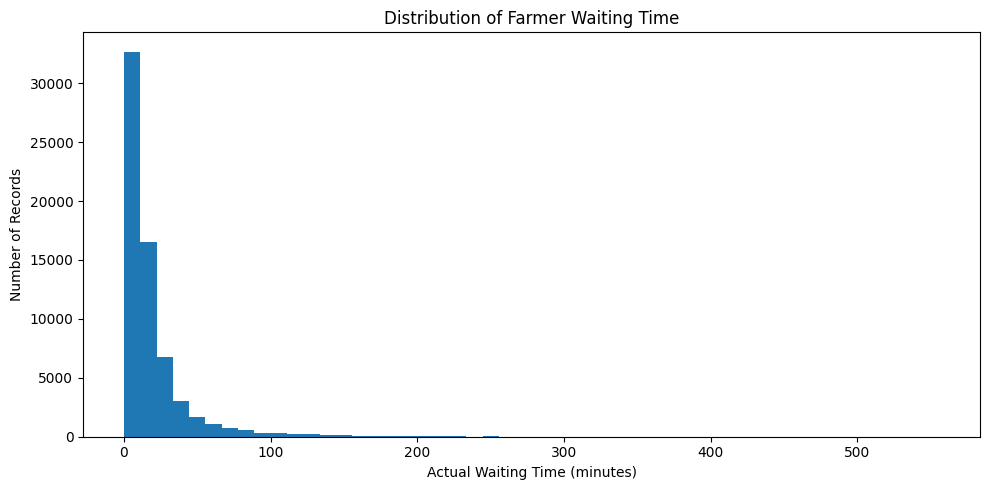

In [ ]:
# ============================================================
# STEP 2B — WAITING TIME DISTRIBUTION (CORRECTED)
# ============================================================

import matplotlib.pyplot as plt

wait = df["actual_wait_time_min"]

print("=" * 60)
print("WAITING TIME ANALYSIS")
print("=" * 60)

print(f"Mean waiting time   : {wait.mean():.2f} minutes")
print(f"Median waiting time : {wait.median():.2f} minutes")
print(f"Minimum             : {wait.min():.2f} minutes")
print(f"Maximum             : {wait.max():.2f} minutes")

print("\nPercentiles:")

for p in [50, 75, 90, 95, 99]:
    value = wait.quantile(p / 100)
    print(f"{p}th percentile     : {value:.2f} minutes")

print("\nWaiting-time categories:")

categories = pd.cut(
    wait,
    bins=[-0.01, 5, 15, 30, 60, float("inf")],
    labels=[
        "0–5 min",
        "5–15 min",
        "15–30 min",
        "30–60 min",
        "60+ min"
    ]
)

print(categories.value_counts().sort_index())

# Plot
plt.figure(figsize=(10, 5))

plt.hist(wait, bins=50)

plt.xlabel("Actual Waiting Time (minutes)")
plt.ylabel("Number of Records")
plt.title("Distribution of Farmer Waiting Time")

plt.tight_layout()
plt.show()

QUEUE vs WAITING TIME ANALYSIS

Correlation between current queue and waiting time: 0.859

Waiting time by queue size:


,current_queue,count,mean,median
0,0,18300,4.030416,3.230293
1,1,5671,7.075438,6.102036
2,2,5938,9.775489,8.730873
3,3,5965,12.559697,11.149868
4,4,5416,15.286904,13.742881
5,5,4791,18.211665,16.424187
6,6,4030,21.183049,18.911472
7,7,3179,24.636460,22.275665
8,8,2451,27.772696,24.978201
9,9,1865,32.887471,29.494687


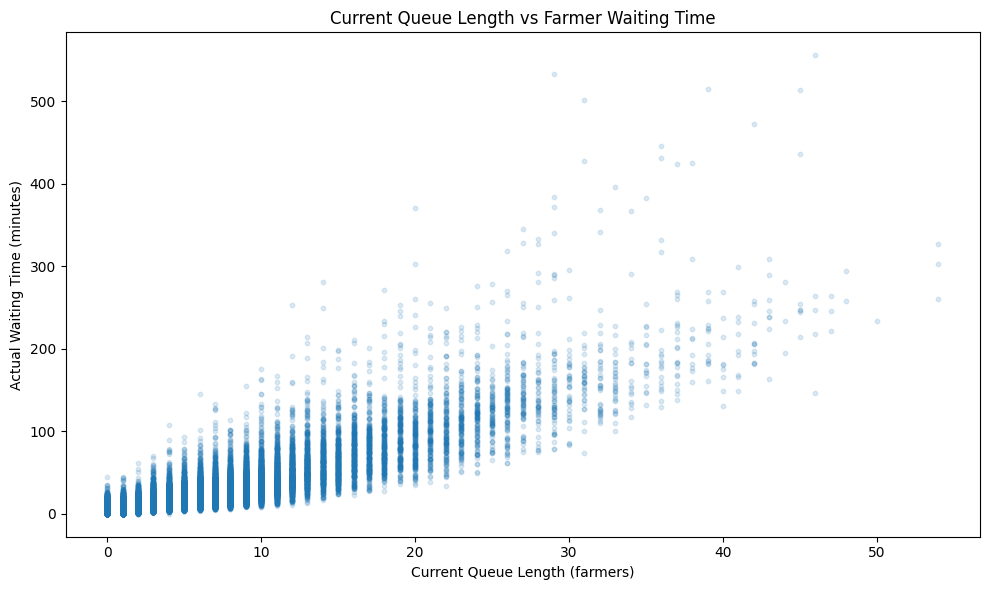

In [ ]:
# ============================================================
# STEP 2C — CURRENT QUEUE vs ACTUAL WAITING TIME
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("QUEUE vs WAITING TIME ANALYSIS")
print("=" * 60)

# Correlation
correlation = df["current_queue"].corr(df["actual_wait_time_min"])

print(f"\nCorrelation between current queue and waiting time: "
      f"{correlation:.3f}")

# Summary by queue size
queue_summary = (
    df.groupby("current_queue")["actual_wait_time_min"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

print("\nWaiting time by queue size:")
display(queue_summary.head(15))

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["current_queue"],
    df["actual_wait_time_min"],
    alpha=0.15,
    s=10
)

plt.xlabel("Current Queue Length (farmers)")
plt.ylabel("Actual Waiting Time (minutes)")
plt.title("Current Queue Length vs Farmer Waiting Time")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 2D — NUMERIC FEATURE CORRELATION WITH WAITING TIME
# ============================================================

import pandas as pd
import numpy as np

# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation with target
correlation_with_wait = (
    numeric_df.corr()["actual_wait_time_min"]
    .drop("actual_wait_time_min")
    .sort_values(key=abs, ascending=False)
)

print("=" * 60)
print("FEATURE CORRELATION WITH ACTUAL WAITING TIME")
print("=" * 60)

display(
    correlation_with_wait.to_frame("correlation")
)

print("\nTop 10 features by absolute correlation:")

top_10 = correlation_with_wait.abs().sort_values(ascending=False).head(10)

for feature in top_10.index:
    print(
        f"{feature:30s} : "
        f"{correlation_with_wait[feature]:+.3f}"
    )

FEATURE CORRELATION WITH ACTUAL WAITING TIME


,correlation
current_queue,0.859380
centre_utilization,0.720084
arrival_service_ratio,0.508242
active_counters,-0.393717
bookings_next_2h,0.281679
avg_processing_time_min,0.268878
quantity_total_kg,0.204087
hour_cos,-0.193559
arrivals_last_1h,0.170847
completed_last_1h,-0.136122



Top 10 features by absolute correlation:
current_queue                  : +0.859
centre_utilization             : +0.720
arrival_service_ratio          : +0.508
active_counters                : -0.394
bookings_next_2h               : +0.282
avg_processing_time_min        : +0.269
quantity_total_kg              : +0.204
hour_cos                       : -0.194
arrivals_last_1h               : +0.171
completed_last_1h              : -0.136


In [ ]:
# ============================================================
# STEP 2E — CENTRE-WISE WAITING TIME ANALYSIS
# ============================================================

centre_analysis = (
    df.groupby("centre_id")["actual_wait_time_min"]
      .agg(
          records="count",
          mean_wait="mean",
          median_wait="median",
          max_wait="max",
          avg_queue="mean",
          avg_utilization="mean"
      )
      .sort_values("mean_wait", ascending=False)
)

print("=" * 70)
print("CENTRE-WISE WAITING TIME ANALYSIS")
print("=" * 70)

display(centre_analysis)

print("\nOverall centre statistics:")
print(f"Highest mean waiting time : "
      f"{centre_analysis['mean_wait'].max():.2f} min")
print(f"Lowest mean waiting time  : "
      f"{centre_analysis['mean_wait'].min():.2f} min")

print("\nDifference between highest and lowest centre:")
difference = (
    centre_analysis["mean_wait"].max()
    - centre_analysis["mean_wait"].min()
)

print(f"{difference:.2f} minutes")

CENTRE-WISE WAITING TIME ANALYSIS


,records,mean_wait,median_wait,max_wait,avg_queue,avg_utilization
centre_id,,,,,,
C004,2160,97.256591,86.661704,555.963339,97.256591,97.256591
C025,2160,48.039533,37.312326,372.500502,48.039533,48.039533
C026,2160,38.292957,28.404046,327.223072,38.292957,38.292957
C005,2160,27.484865,19.573058,370.537393,27.484865,27.484865
C003,2160,25.887643,19.032953,251.327960,25.887643,25.887643
C015,2160,22.432705,17.336377,148.783720,22.432705,22.432705
C007,2160,22.357229,17.674810,129.116338,22.357229,22.357229
C024,2160,20.928357,15.738017,150.941985,20.928357,20.928357
C016,2160,19.197274,15.389974,106.859250,19.197274,19.197274



Overall centre statistics:
Highest mean waiting time : 97.26 min
Lowest mean waiting time  : 4.64 min

Difference between highest and lowest centre:
92.61 minutes


In [ ]:
# ============================================================
# STEP 2F — CHECK FOR SYNTHETIC FEATURE DEPENDENCIES
# ============================================================

import numpy as np

columns_to_check = [
    "current_queue",
    "centre_utilization",
    "actual_wait_time_min"
]

print("=" * 70)
print("CHECKING FEATURE RELATIONSHIPS")
print("=" * 70)

# Check whether columns are exactly identical
for i in range(len(columns_to_check)):
    for j in range(i + 1, len(columns_to_check)):
        col1 = columns_to_check[i]
        col2 = columns_to_check[j]

        identical = np.allclose(
            df[col1].values,
            df[col2].values,
            rtol=0,
            atol=1e-10
        )

        print(f"{col1} == {col2}: {identical}")

# Centre-wise means
check = (
    df.groupby("centre_id")[
        ["current_queue", "centre_utilization", "actual_wait_time_min"]
    ]
    .mean()
)

print("\nCentre-wise mean comparison:")
display(check)

print("\nCorrelation matrix:")
display(check.corr())

# Check number of unique values
print("\nUnique values:")
for col in columns_to_check:
    print(f"{col:25s}: {df[col].nunique():,}")

CHECKING FEATURE RELATIONSHIPS
current_queue == centre_utilization: False
current_queue == actual_wait_time_min: False
centre_utilization == actual_wait_time_min: False

Centre-wise mean comparison:


,current_queue,centre_utilization,actual_wait_time_min
centre_id,,,
C001,3.318056,0.079268,15.302848
C002,3.752315,0.072928,15.798562
C003,5.107407,0.073043,25.887643
C004,16.973611,0.294631,97.256591
C005,4.706019,0.093148,27.484865
C006,3.672222,0.091046,12.910319
C007,4.850926,0.080981,22.357229
C008,3.518056,0.124299,11.416143
C009,3.331019,0.107065,10.434804



Correlation matrix:


,current_queue,centre_utilization,actual_wait_time_min
current_queue,1.000000,0.798211,0.979953
centre_utilization,0.798211,1.000000,0.705886
actual_wait_time_min,0.979953,0.705886,1.000000



Unique values:
current_queue            : 51
centre_utilization       : 960
actual_wait_time_min     : 62,087


HOUR-WISE WAITING TIME ANALYSIS


,hour,records,mean_wait,median_wait,mean_queue,mean_utilization
0,8,5400,14.842091,10.419301,3.289259,0.081435
1,9,5400,14.922773,9.795450,3.267037,0.081257
2,10,5400,25.037123,17.188051,5.456481,0.124924
3,11,5400,27.731198,17.463390,6.244444,0.129781
4,12,5400,25.345032,14.531089,5.750185,0.117444
5,13,5400,25.788491,15.156736,5.788148,0.117765
6,14,5400,20.834681,11.549946,4.830370,0.098643
7,15,5400,19.930269,11.484435,4.505185,0.096539
8,16,5400,15.729808,8.654394,3.545000,0.078918
9,17,5400,14.895529,8.575528,3.278333,0.076836



Highest average waiting hour:
Hour 11: 27.73 minutes

Lowest average waiting hour:
Hour 19: 10.33 minutes


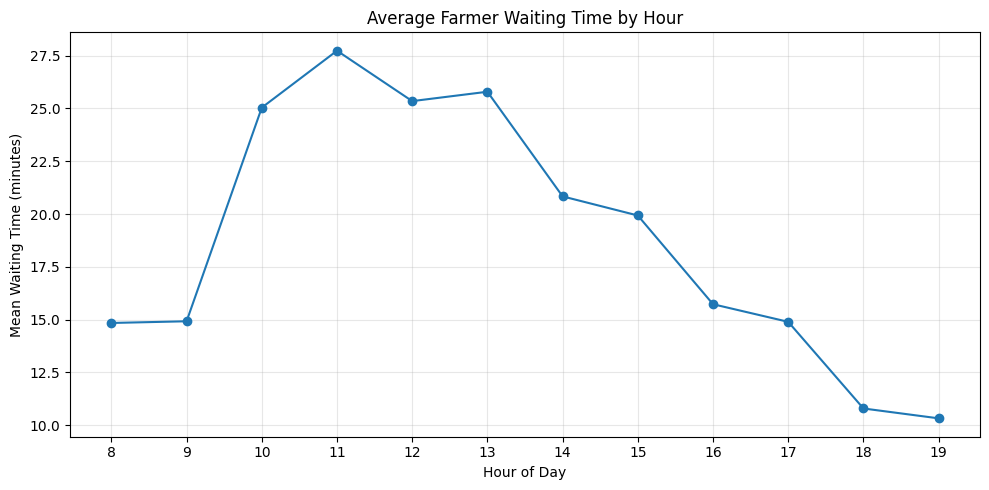

In [ ]:
# ============================================================
# STEP 2G — HOUR-WISE WAITING TIME ANALYSIS (CORRECTED)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

hour_analysis = (
    df.groupby("hour")
      .agg(
          records=("actual_wait_time_min", "count"),
          mean_wait=("actual_wait_time_min", "mean"),
          median_wait=("actual_wait_time_min", "median"),
          mean_queue=("current_queue", "mean"),
          mean_utilization=("centre_utilization", "mean")
      )
      .reset_index()
)

print("=" * 70)
print("HOUR-WISE WAITING TIME ANALYSIS")
print("=" * 70)

display(hour_analysis)

# Highest average waiting hour
highest_hour = hour_analysis.loc[
    hour_analysis["mean_wait"].idxmax()
]

# Lowest average waiting hour
lowest_hour = hour_analysis.loc[
    hour_analysis["mean_wait"].idxmin()
]

print("\nHighest average waiting hour:")
print(
    f"Hour {int(highest_hour['hour'])}: "
    f"{highest_hour['mean_wait']:.2f} minutes"
)

print("\nLowest average waiting hour:")
print(
    f"Hour {int(lowest_hour['hour'])}: "
    f"{lowest_hour['mean_wait']:.2f} minutes"
)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    hour_analysis["hour"],
    hour_analysis["mean_wait"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Mean Waiting Time (minutes)")
plt.title("Average Farmer Waiting Time by Hour")

plt.xticks(hour_analysis["hour"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 2H — CROP-WISE WAITING TIME ANALYSIS
# ============================================================

crop_analysis = (
    df.groupby("crop")
      .agg(
          records=("actual_wait_time_min", "count"),
          mean_wait=("actual_wait_time_min", "mean"),
          median_wait=("actual_wait_time_min", "median"),
          mean_queue=("current_queue", "mean"),
          mean_processing_time=("avg_processing_time_min", "mean")
      )
      .reset_index()
      .sort_values("mean_wait", ascending=False)
)

print("=" * 70)
print("CROP-WISE WAITING TIME ANALYSIS")
print("=" * 70)

display(crop_analysis)

print("\nHighest mean waiting crop:")
highest = crop_analysis.iloc[0]
print(f"{highest['crop']}: {highest['mean_wait']:.2f} minutes")

print("\nLowest mean waiting crop:")
lowest = crop_analysis.iloc[-1]
print(f"{lowest['crop']}: {lowest['mean_wait']:.2f} minutes")

CROP-WISE WAITING TIME ANALYSIS


,crop,records,mean_wait,median_wait,mean_queue,mean_processing_time
0,Cotton,9715,23.198636,13.293555,4.665260,8.221913
2,Paddy,21901,19.892961,11.601282,4.355463,7.509078
3,Wheat,18238,17.539240,10.332233,4.092115,6.956969
1,Maize,14946,16.086663,9.697837,3.990232,6.533605



Highest mean waiting crop:
Cotton: 23.20 minutes

Lowest mean waiting crop:
Maize: 16.09 minutes


In [ ]:
print("Unique hour values:")
print(sorted(df["hour"].unique()))

print("\nMinimum hour:", df["hour"].min())
print("Maximum hour:", df["hour"].max())

print("\nHour value counts:")
print(df["hour"].value_counts().sort_index())

Unique hour values:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

Minimum hour: 8
Maximum hour: 19

Hour value counts:
hour
8     5400
9     5400
10    5400
11    5400
12    5400
13    5400
14    5400
15    5400
16    5400
17    5400
18    5400
19    5400
Name: count, dtype: int64


In [ ]:
print("Waiting time above 60 minutes:")
print((df["actual_wait_time_min"] > 60).sum())

print("\nWaiting time above 120 minutes:")
print((df["actual_wait_time_min"] > 120).sum())

print("\nWaiting time above 180 minutes:")
print((df["actual_wait_time_min"] > 180).sum())

print("\nWaiting time above 300 minutes:")
print((df["actual_wait_time_min"] > 300).sum())

print("\nTop 10 highest waiting times:")
print(
    df[["centre_id", "date", "hour", "current_queue", "active_counters",
        "centre_utilization", "actual_wait_time_min"]]
    .sort_values("actual_wait_time_min", ascending=False)
    .head(10)
    .to_string(index=False)
)

Waiting time above 60 minutes:
3661

Waiting time above 120 minutes:
958

Waiting time above 180 minutes:
270

Waiting time above 300 minutes:
33

Top 10 highest waiting times:
centre_id       date  hour  current_queue  active_counters  centre_utilization  actual_wait_time_min
     C004 2026-05-25    15             46                1            0.567308            555.963339
     C004 2026-01-27     9             29                1            0.432692            533.717610
     C004 2026-01-21    13             39                1            0.471154            514.847542
     C004 2026-03-09    11             45                1            0.605769            513.727598
     C004 2026-04-15    12             31                1            0.461538            501.910775
     C004 2026-02-02    13             42                1            0.576923            472.878259
     C004 2026-05-13    13             36                1            0.548077            445.702681
     C004 2026-

In [ ]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Chronological split
train_df = df[df["date"] <= "2026-04-30"].copy()
val_df = df[
    (df["date"] >= "2026-05-01") &
    (df["date"] <= "2026-05-31")
].copy()
test_df = df[df["date"] >= "2026-06-01"].copy()

print("TRAIN")
print("Rows:", len(train_df))
print("Date range:", train_df["date"].min().date(), "to", train_df["date"].max().date())

print("\nVALIDATION")
print("Rows:", len(val_df))
print("Date range:", val_df["date"].min().date(), "to", val_df["date"].max().date())

print("\nTEST")
print("Rows:", len(test_df))
print("Date range:", test_df["date"].min().date(), "to", test_df["date"].max().date())

print("\nTotal rows:", len(train_df) + len(val_df) + len(test_df))
print("Original rows:", len(df))

TRAIN
Rows: 43200
Date range: 2026-01-01 to 2026-04-30

VALIDATION
Rows: 11160
Date range: 2026-05-01 to 2026-05-31

TEST
Rows: 10440
Date range: 2026-06-01 to 2026-06-29

Total rows: 64800
Original rows: 64800


In [ ]:
# Target variable
target = "actual_wait_time_min"

# Features available for prediction
categorical_features = [
    "centre_id",
    "crop"
]

numeric_features = [
    "hour",
    "day_of_week",
    "weather_factor",
    "current_queue",
    "bookings_next_2h",
    "arrivals_last_1h",
    "completed_last_1h",
    "active_counters",
    "centre_capacity_farmers",
    "hourly_capacity_farmers",
    "historical_avg_queue",
    "historical_avg_wait_min",
    "quantity_total_kg",
    "avg_quantity_per_farmer_kg",
    "avg_processing_time_min",
    "centre_utilization",
    "arrival_service_ratio",
    "hour_sin",
    "hour_cos"
]

all_features = categorical_features + numeric_features

# Create X and y for each split
X_train = train_df[all_features].copy()
y_train = train_df[target].copy()

X_val = val_df[all_features].copy()
y_val = val_df[target].copy()

X_test = test_df[all_features].copy()
y_test = test_df[target].copy()

print("Number of features:", len(all_features))
print("\nCategorical features:", categorical_features)
print("\nNumeric features:", len(numeric_features))

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTarget:")
print("Training mean:", round(y_train.mean(), 2))
print("Validation mean:", round(y_val.mean(), 2))
print("Test mean:", round(y_test.mean(), 2))

Number of features: 21

Categorical features: ['centre_id', 'crop']

Numeric features: 19

Shapes:
X_train: (43200, 21)
y_train: (43200,)
X_val: (11160, 21)
y_val: (11160,)
X_test: (10440, 21)
y_test: (10440,)

Target:
Training mean: 19.07
Validation mean: 19.19
Test mean: 17.58


In [ ]:
print("Checking for target leakage...\n")

# 1. Check whether target is present in feature list
print("Target present in features:", target in all_features)

# 2. Check exact column overlap
overlap = set(all_features).intersection({target})
print("Feature/target overlap:", overlap)

# 3. Check whether any feature is exactly equal to the target
exact_matches = []

for feature in all_features:
    if feature in X_train.columns and pd.api.types.is_numeric_dtype(X_train[feature]):
        if X_train[feature].equals(y_train):
            exact_matches.append(feature)

print("Features exactly equal to target:", exact_matches)

# 4. Check missing values
print("\nMissing values in training features:", X_train.isna().sum().sum())
print("Missing values in validation features:", X_val.isna().sum().sum())
print("Missing values in test features:", X_test.isna().sum().sum())

# 5. Check infinite values in numerical features
train_inf = np.isinf(X_train[numeric_features]).sum().sum()
val_inf = np.isinf(X_val[numeric_features]).sum().sum()
test_inf = np.isinf(X_test[numeric_features]).sum().sum()

print("\nInfinite values:")
print("Train:", train_inf)
print("Validation:", val_inf)
print("Test:", test_inf)

Checking for target leakage...

Target present in features: False
Feature/target overlap: set()
Features exactly equal to target: []

Missing values in training features: 0
Missing values in validation features: 0
Missing values in test features: 0

Infinite values:
Train: 0
Validation: 0
Test: 0


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# Check the preprocessing object
print("Preprocessor created successfully.")
print("\nCategorical features:", categorical_features)
print("Numeric features:", len(numeric_features))
print("Total original features:", len(all_features))

Preprocessor created successfully.

Categorical features: ['centre_id', 'crop']
Numeric features: 19
Total original features: 21


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_baseline(data):
    counters = data["active_counters"].clip(lower=1)

    baseline_wait = (
        data["current_queue"]
        * data["avg_processing_time_min"]
        / counters
    )

    return baseline_wait

# Baseline predictions
baseline_train = calculate_baseline(train_df)
baseline_val = calculate_baseline(val_df)
baseline_test = calculate_baseline(test_df)

# Evaluation function
def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mae, rmse

# Evaluate baseline
train_mae, train_rmse = evaluate_predictions(y_train, baseline_train)
val_mae, val_rmse = evaluate_predictions(y_val, baseline_val)
test_mae, test_rmse = evaluate_predictions(y_test, baseline_test)

print("BASELINE WAITING-TIME MODEL")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f} minutes")
print(f"Train RMSE: {train_rmse:.2f} minutes")

print(f"\nValidation MAE : {val_mae:.2f} minutes")
print(f"Validation RMSE: {val_rmse:.2f} minutes")

print(f"\nTest MAE : {test_mae:.2f} minutes")
print(f"Test RMSE: {test_rmse:.2f} minutes")

BASELINE WAITING-TIME MODEL
----------------------------------------
Train MAE : 6.82 minutes
Train RMSE: 10.27 minutes

Validation MAE : 6.89 minutes
Validation RMSE: 10.17 minutes

Test MAE : 6.50 minutes
Test RMSE: 9.49 minutes


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest model
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                max_features="sqrt"
            )
        )
    ]
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Random Forest training completed successfully.")



Training Random Forest...
Random Forest training completed successfully.


In [ ]:
# Generate predictions
rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

# Evaluate Random Forest
rf_train_mae, rf_train_rmse = evaluate_predictions(y_train, rf_train_pred)
rf_val_mae, rf_val_rmse = evaluate_predictions(y_val, rf_val_pred)
rf_test_mae, rf_test_rmse = evaluate_predictions(y_test, rf_test_pred)

print("RANDOM FOREST RESULTS")
print("-" * 40)

print(f"Train MAE : {rf_train_mae:.2f} minutes")
print(f"Train RMSE: {rf_train_rmse:.2f} minutes")

print(f"\nValidation MAE : {rf_val_mae:.2f} minutes")
print(f"Validation RMSE: {rf_val_rmse:.2f} minutes")

print(f"\nTest MAE : {rf_test_mae:.2f} minutes")
print(f"Test RMSE: {rf_test_rmse:.2f} minutes")

print("\nBASELINE vs RANDOM FOREST — TEST SET")
print("-" * 40)
print(f"Baseline MAE      : {test_mae:.2f} minutes")
print(f"Random Forest MAE : {rf_test_mae:.2f} minutes")

improvement = ((test_mae - rf_test_mae) / test_mae) * 100
print(f"MAE improvement   : {improvement:.2f}%")

RANDOM FOREST RESULTS
----------------------------------------
Train MAE : 1.07 minutes
Train RMSE: 2.60 minutes

Validation MAE : 2.84 minutes
Validation RMSE: 7.10 minutes

Test MAE : 2.63 minutes
Test RMSE: 5.92 minutes

BASELINE vs RANDOM FOREST — TEST SET
----------------------------------------
Baseline MAE      : 6.50 minutes
Random Forest MAE : 2.63 minutes
MAE improvement   : 59.61%


In [ ]:
from sklearn.metrics import r2_score

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("RANDOM FOREST R² RESULTS")
print("-" * 40)

print(f"Train R²      : {rf_train_r2:.4f}")
print(f"Validation R² : {rf_val_r2:.4f}")
print(f"Test R²       : {rf_test_r2:.4f}")

RANDOM FOREST R² RESULTS
----------------------------------------
Train R²      : 0.9910
Validation R² : 0.9348
Test R²       : 0.9408


In [ ]:
# Get the fitted preprocessing step
fitted_preprocessor = rf_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importances
importances = rf_model.named_steps["model"].feature_importances_

# Create feature-importance table
feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Random Forest Features")
print("-" * 50)
print(feature_importance_df.head(20).to_string(index=False))

Top 20 Random Forest Features
--------------------------------------------------
                            feature  importance
             numeric__current_queue    0.277823
        numeric__centre_utilization    0.173503
     numeric__arrival_service_ratio    0.111437
           numeric__active_counters    0.082164
   numeric__centre_capacity_farmers    0.075449
        categorical__centre_id_C004    0.049603
   numeric__avg_processing_time_min    0.035022
          numeric__bookings_next_2h    0.024904
         numeric__completed_last_1h    0.024859
         numeric__quantity_total_kg    0.014827
        categorical__centre_id_C025    0.014540
   numeric__hourly_capacity_farmers    0.013595
          numeric__arrivals_last_1h    0.012589
      numeric__historical_avg_queue    0.009214
   numeric__historical_avg_wait_min    0.008934
numeric__avg_quantity_per_farmer_kg    0.008863
                  numeric__hour_cos    0.008778
                      numeric__hour    0.008122
       

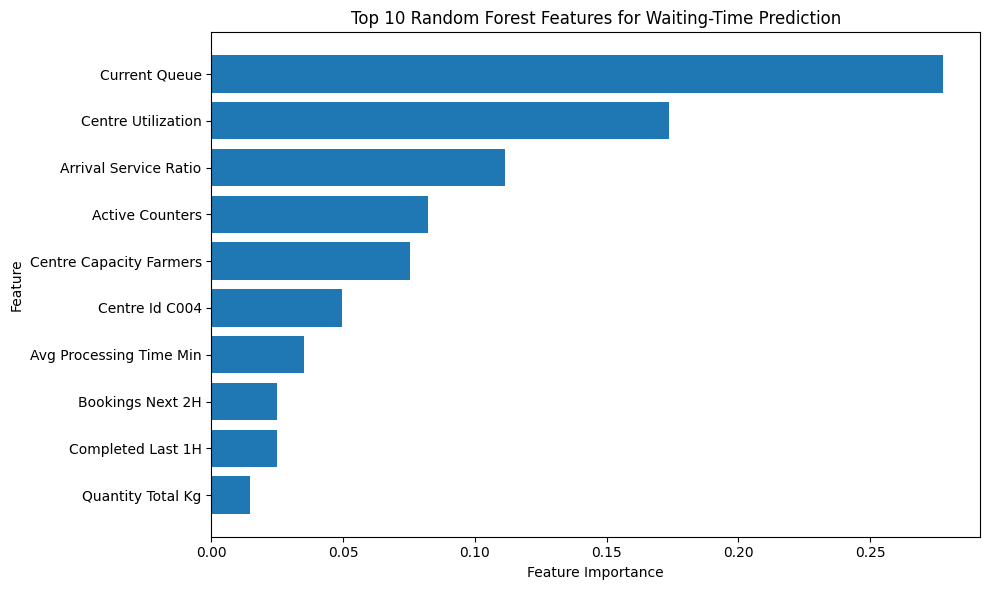

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10).copy()

# Make feature names presentation-friendly
top_features["feature"] = (
    top_features["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

top_features = top_features.sort_values("importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features for Waiting-Time Prediction")

plt.tight_layout()
plt.show()

In [ ]:
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
    print("XGBoost is available.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost version: 3.4.1
XGBoost is available.


In [ ]:
from xgboost import XGBRegressor

# XGBoost model
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training XGBoost...")

xgb_model.fit(X_train, y_train)

print("XGBoost training completed successfully.")

Training XGBoost...
XGBoost training completed successfully.


In [ ]:
# Generate predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

# Evaluate XGBoost
xgb_train_mae, xgb_train_rmse = evaluate_predictions(y_train, xgb_train_pred)
xgb_val_mae, xgb_val_rmse = evaluate_predictions(y_val, xgb_val_pred)
xgb_test_mae, xgb_test_rmse = evaluate_predictions(y_test, xgb_test_pred)

# R²
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_val_r2 = r2_score(y_val, xgb_val_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print("XGBOOST RESULTS")
print("-" * 40)

print(f"Train MAE : {xgb_train_mae:.2f} minutes")
print(f"Train RMSE: {xgb_train_rmse:.2f} minutes")
print(f"Train R²  : {xgb_train_r2:.4f}")

print(f"\nValidation MAE : {xgb_val_mae:.2f} minutes")
print(f"Validation RMSE: {xgb_val_rmse:.2f} minutes")
print(f"Validation R²  : {xgb_val_r2:.4f}")

print(f"\nTest MAE : {xgb_test_mae:.2f} minutes")
print(f"Test RMSE: {xgb_test_rmse:.2f} minutes")
print(f"Test R²  : {xgb_test_r2:.4f}")

print("\nTEST SET COMPARISON")
print("-" * 40)
print(f"Baseline MAE      : {test_mae:.2f} minutes")
print(f"Random Forest MAE : {rf_test_mae:.2f} minutes")
print(f"XGBoost MAE       : {xgb_test_mae:.2f} minutes")

XGBOOST RESULTS
----------------------------------------
Train MAE : 1.65 minutes
Train RMSE: 2.76 minutes
Train R²  : 0.9898

Validation MAE : 2.05 minutes
Validation RMSE: 4.55 minutes
Validation R²  : 0.9732

Test MAE : 1.91 minutes
Test RMSE: 3.97 minutes
Test R²  : 0.9734

TEST SET COMPARISON
----------------------------------------
Baseline MAE      : 6.50 minutes
Random Forest MAE : 2.63 minutes
XGBoost MAE       : 1.91 minutes


In [ ]:

# Get the fitted preprocessing step
xgb_preprocessor = xgb_model.named_steps["preprocessor"]

# Get transformed feature names
xgb_feature_names = xgb_preprocessor.get_feature_names_out()

# Get XGBoost feature importance
xgb_importances = xgb_model.named_steps["model"].feature_importances_

# Create feature-importance table
xgb_feature_importance_df = (
    pd.DataFrame({
        "feature": xgb_feature_names,
        "importance": xgb_importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 XGBoost Features")
print("-" * 50)
print(xgb_feature_importance_df.head(20).to_string(index=False))

Top 20 XGBoost Features
--------------------------------------------------
                         feature  importance
          numeric__current_queue    0.437477
        numeric__active_counters    0.147383
     numeric__centre_utilization    0.129847
  numeric__arrival_service_ratio    0.056365
     categorical__centre_id_C025    0.033267
numeric__avg_processing_time_min    0.032015
     categorical__centre_id_C026    0.017225
     categorical__centre_id_C016    0.016685
         numeric__weather_factor    0.015714
     categorical__centre_id_C004    0.013518
      numeric__completed_last_1h    0.013234
       numeric__bookings_next_2h    0.010405
numeric__centre_capacity_farmers    0.009950
numeric__hourly_capacity_farmers    0.009222
     categorical__centre_id_C023    0.005666
     categorical__centre_id_C015    0.005354
               numeric__hour_cos    0.003453
      numeric__quantity_total_kg    0.003417
        categorical__crop_Cotton    0.003190
               numeric__h

In [ ]:
# 4. Congestion Classification

### Objective
Predict the current procurement-centre congestion level using operational and historical features.

### Congestion Levels
- **NORMAL** – Centre is operating smoothly
- **MODERATE** – Increasing workload; monitoring required
- **HIGH** – Significant congestion; intervention may be required
- **CRITICAL** – Severe congestion; load balancing or farmer redirection may be required

### Why this model?
Waiting-time prediction tells us **how long a farmer may wait**, while congestion classification tells the system **how urgently a procurement centre needs intervention**.

### Model Pipeline
Operational Data → Feature Engineering → Congestion Classification → Congestion Level → Centre/Queue Management Action

> **Important:** `future_queue_1h` is not used as an input feature because it represents future information and would cause target leakage.

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Per-class performance

In [ ]:
congestion_file = "/content/06_congestion_classification_data.csv"

congestion_df = pd.read_csv(congestion_file)

print("Shape:", congestion_df.shape)

print("\nColumns:")
print(congestion_df.columns.tolist())

print("\nTarget distribution:")
print(congestion_df["congestion_level"].value_counts())

print("\nMissing values:")
print(congestion_df.isna().sum().sum())

Shape: (64800, 22)

Columns:
['centre_id', 'date', 'hour', 'day_of_week', 'crop', 'weather_factor', 'current_queue', 'bookings_next_2h', 'arrivals_last_1h', 'completed_last_1h', 'active_counters', 'centre_capacity_farmers', 'hourly_capacity_farmers', 'historical_avg_queue', 'historical_avg_wait_min', 'quantity_total_kg', 'avg_processing_time_min', 'centre_utilization', 'arrival_service_ratio', 'hour_sin', 'hour_cos', 'congestion_level']

Target distribution:
congestion_level
NORMAL      47333
MODERATE    15331
HIGH         1776
CRITICAL      360
Name: count, dtype: int64

Missing values:
0


In [ ]:
# Convert date to datetime
congestion_df["date"] = pd.to_datetime(congestion_df["date"])

# Chronological train-validation-test split
congestion_train = congestion_df[
    congestion_df["date"] <= "2026-04-30"
].copy()

congestion_val = congestion_df[
    (congestion_df["date"] >= "2026-05-01") &
    (congestion_df["date"] <= "2026-05-31")
].copy()

congestion_test = congestion_df[
    congestion_df["date"] >= "2026-06-01"
].copy()

print("Train shape:", congestion_train.shape)
print("Validation shape:", congestion_val.shape)
print("Test shape:", congestion_test.shape)

print("\nTrain dates:",
      congestion_train["date"].min().date(),
      "to",
      congestion_train["date"].max().date())

print("Validation dates:",
      congestion_val["date"].min().date(),
      "to",
      congestion_val["date"].max().date())

print("Test dates:",
      congestion_test["date"].min().date(),
      "to",
      congestion_test["date"].max().date())

Train shape: (43200, 22)
Validation shape: (11160, 22)
Test shape: (10440, 22)

Train dates: 2026-01-01 to 2026-04-30
Validation dates: 2026-05-01 to 2026-05-31
Test dates: 2026-06-01 to 2026-06-29


In [ ]:
# Target column
congestion_target = "congestion_level"

# Categorical features
congestion_categorical_features = [
    "centre_id",
    "crop"
]

# Numerical features
congestion_numeric_features = [
    "hour",
    "day_of_week",
    "weather_factor",
    "current_queue",
    "bookings_next_2h",
    "arrivals_last_1h",
    "completed_last_1h",
    "active_counters",
    "centre_capacity_farmers",
    "hourly_capacity_farmers",
    "historical_avg_queue",
    "historical_avg_wait_min",
    "quantity_total_kg",
    "avg_processing_time_min",
    "centre_utilization",
    "arrival_service_ratio",
    "hour_sin",
    "hour_cos"
]

# Combine all model features
congestion_features = (
    congestion_categorical_features +
    congestion_numeric_features
)

# Create X and y
X_congestion_train = congestion_train[congestion_features]
y_congestion_train = congestion_train[congestion_target]

X_congestion_val = congestion_val[congestion_features]
y_congestion_val = congestion_val[congestion_target]

X_congestion_test = congestion_test[congestion_features]
y_congestion_test = congestion_test[congestion_target]

print("Number of features:", len(congestion_features))

print("X_train:", X_congestion_train.shape)
print("y_train:", y_congestion_train.shape)

print("X_val:", X_congestion_val.shape)
print("y_val:", y_congestion_val.shape)

print("X_test:", X_congestion_test.shape)
print("y_test:", y_congestion_test.shape)

print("\nTarget classes:")
print(y_congestion_train.value_counts())

Number of features: 20
X_train: (43200, 20)
y_train: (43200,)
X_val: (11160, 20)
y_val: (11160,)
X_test: (10440, 20)
y_test: (10440,)

Target classes:
congestion_level
NORMAL      31378
MODERATE    10327
HIGH         1235
CRITICAL      260
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing pipeline
congestion_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            congestion_categorical_features
        ),
        (
            "numeric",
            "passthrough",
            congestion_numeric_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# 4.3 Baseline Congestion Classifier

A rule-based classifier is used as the baseline.

The baseline assigns congestion levels using the current queue:

- **NORMAL:** queue < 5
- **MODERATE:** queue 5–9
- **HIGH:** queue 10–19
- **CRITICAL:** queue ≥ 20

This baseline represents a simple system that makes decisions using only the current queue and does not consider multiple operational factors.

In [ ]:
def baseline_congestion_classifier(data):
    """
    Rule-based congestion classifier using current queue size.
    """
    conditions = [
        data["current_queue"] < 5,
        data["current_queue"].between(5, 9),
        data["current_queue"].between(10, 19),
        data["current_queue"] >= 20
    ]

    choices = [
        "NORMAL",
        "MODERATE",
        "HIGH",
        "CRITICAL"
    ]

    return np.select(
        conditions,
        choices,
        default="NORMAL"
    )


# Generate baseline predictions
baseline_congestion_pred = baseline_congestion_classifier(
    congestion_test
)

print("Baseline predictions created successfully.")

print("\nPrediction distribution:")
print(pd.Series(baseline_congestion_pred).value_counts())

Baseline predictions created successfully.

Prediction distribution:
NORMAL      6837
MODERATE    2603
HIGH         819
CRITICAL     181
Name: count, dtype: int64


In [ ]:
# ============================================================
# 4.4 Baseline Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Calculate evaluation metrics
baseline_accuracy = accuracy_score(
    y_congestion_test,
    baseline_congestion_pred
)

baseline_precision = precision_score(
    y_congestion_test,
    baseline_congestion_pred,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_congestion_test,
    baseline_congestion_pred,
    average="weighted",
    zero_division=0
)

baseline_f1_weighted = f1_score(
    y_congestion_test,
    baseline_congestion_pred,
    average="weighted",
    zero_division=0
)

baseline_f1_macro = f1_score(
    y_congestion_test,
    baseline_congestion_pred,
    average="macro",
    zero_division=0
)

print("Baseline Accuracy       :", round(baseline_accuracy, 4))
print("Baseline Precision      :", round(baseline_precision, 4))
print("Baseline Recall         :", round(baseline_recall, 4))
print("Baseline Weighted F1    :", round(baseline_f1_weighted, 4))
print("Baseline Macro F1      :", round(baseline_f1_macro, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_congestion_test,
        baseline_congestion_pred,
        labels=["NORMAL", "MODERATE", "HIGH", "CRITICAL"],
        zero_division=0
    )
)

Baseline Accuracy       : 0.7001
Baseline Precision      : 0.7647
Baseline Recall         : 0.7001
Baseline Weighted F1    : 0.7264
Baseline Macro F1      : 0.4435

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.78      0.83      7828
    MODERATE       0.40      0.45      0.42      2334
        HIGH       0.13      0.46      0.21       239
    CRITICAL       0.19      0.87      0.31        39

    accuracy                           0.70     10440
   macro avg       0.40      0.64      0.44     10440
weighted avg       0.76      0.70      0.73     10440



In [ ]:

# ============================================================
# 4.5 Target Encoding for XGBoost Congestion Classifier
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Create label encoder
congestion_label_encoder = LabelEncoder()

# Fit only on training target
congestion_label_encoder.fit(y_congestion_train)

# Encode train, validation and test targets
y_congestion_train_encoded = congestion_label_encoder.transform(
    y_congestion_train
)

y_congestion_val_encoded = congestion_label_encoder.transform(
    y_congestion_val
)

y_congestion_test_encoded = congestion_label_encoder.transform(
    y_congestion_test
)

print("Class mapping:")

for class_name, class_number in zip(
    congestion_label_encoder.classes_,
    range(len(congestion_label_encoder.classes_))
):
    print(f"{class_name} -> {class_number}")

print("\nEncoded target shapes:")
print("Train:", y_congestion_train_encoded.shape)
print("Validation:", y_congestion_val_encoded.shape)
print("Test:", y_congestion_test_encoded.shape)

Class mapping:
CRITICAL -> 0
HIGH -> 1
MODERATE -> 2
NORMAL -> 3

Encoded target shapes:
Train: (43200,)
Validation: (11160,)
Test: (10440,)


In [ ]:
# ============================================================
# 4.6 Class Weight Calculation
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get encoded class numbers
classes = np.unique(y_congestion_train_encoded)

# Calculate balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_congestion_train_encoded
)

# Store weights in a dictionary
congestion_class_weights = dict(
    zip(classes, class_weights)
)

print("Class weights:")

for class_number, weight in congestion_class_weights.items():
    class_name = congestion_label_encoder.inverse_transform(
        [class_number]
    )[0]

    print(
        f"{class_name:10s} -> "
        f"class {class_number} -> "
        f"weight {weight:.4f}"
    )

Class weights:
CRITICAL   -> class 0 -> weight 41.5385
HIGH       -> class 1 -> weight 8.7449
MODERATE   -> class 2 -> weight 1.0458
NORMAL     -> class 3 -> weight 0.3442


In [ ]:
# ============================================================
# 4.7 Train XGBoost Congestion Classifier
# ============================================================

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Create sample weights for the training data
train_sample_weights = np.array([
    congestion_class_weights[class_label]
    for class_label in y_congestion_train_encoded
])

# Create XGBoost classifier
xgb_congestion_model = Pipeline(
    steps=[
        (
            "preprocessor",
            congestion_preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=4,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
xgb_congestion_model.fit(
    X_congestion_train,
    y_congestion_train_encoded,
    model__sample_weight=train_sample_weights
)

print("XGBoost congestion classifier trained successfully.")

XGBoost congestion classifier trained successfully.


In [ ]:
# ============================================================
# 4.8 Evaluate XGBoost Congestion Classifier
# ============================================================

# Generate predictions
xgb_congestion_val_pred = xgb_congestion_model.predict(
    X_congestion_val
)

xgb_congestion_test_pred = xgb_congestion_model.predict(
    X_congestion_test
)

# Convert encoded predictions back to class names
xgb_congestion_val_labels = congestion_label_encoder.inverse_transform(
    xgb_congestion_val_pred.astype(int)
)

xgb_congestion_test_labels = congestion_label_encoder.inverse_transform(
    xgb_congestion_test_pred.astype(int)
)

# Validation metrics
val_accuracy = accuracy_score(
    y_congestion_val,
    xgb_congestion_val_labels
)

val_precision = precision_score(
    y_congestion_val,
    xgb_congestion_val_labels,
    average="weighted",
    zero_division=0
)

val_recall = recall_score(
    y_congestion_val,
    xgb_congestion_val_labels,
    average="weighted",
    zero_division=0
)

val_f1_weighted = f1_score(
    y_congestion_val,
    xgb_congestion_val_labels,
    average="weighted",
    zero_division=0
)

val_f1_macro = f1_score(
    y_congestion_val,
    xgb_congestion_val_labels,
    average="macro",
    zero_division=0
)

# Test metrics
test_accuracy = accuracy_score(
    y_congestion_test,
    xgb_congestion_test_labels
)

test_precision = precision_score(
    y_congestion_test,
    xgb_congestion_test_labels,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_congestion_test,
    xgb_congestion_test_labels,
    average="weighted",
    zero_division=0
)

test_f1_weighted = f1_score(
    y_congestion_test,
    xgb_congestion_test_labels,
    average="weighted",
    zero_division=0
)

test_f1_macro = f1_score(
    y_congestion_test,
    xgb_congestion_test_labels,
    average="macro",
    zero_division=0
)

print("========== VALIDATION RESULTS ==========")
print("Accuracy        :", round(val_accuracy, 4))
print("Weighted F1     :", round(val_f1_weighted, 4))
print("Macro F1        :", round(val_f1_macro, 4))

print("\n========== TEST RESULTS ==========")
print("Accuracy        :", round(test_accuracy, 4))
print("Weighted F1     :", round(test_f1_weighted, 4))
print("Macro F1        :", round(test_f1_macro, 4))

print("\n========== TEST CLASSIFICATION REPORT ==========")
print(
    classification_report(
        y_congestion_test,
        xgb_congestion_test_labels,
        labels=["NORMAL", "MODERATE", "HIGH", "CRITICAL"],
        zero_division=0
    )
)

========== VALIDATION RESULTS ==========
Accuracy        : 0.812
Weighted F1     : 0.8218
Macro F1        : 0.7325

========== TEST RESULTS ==========
Accuracy        : 0.8126
Weighted F1     : 0.8242
Macro F1        : 0.6803

========== TEST CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      NORMAL       0.95      0.82      0.88      7828
    MODERATE       0.56      0.80      0.66      2334
        HIGH       0.52      0.74      0.61       239
    CRITICAL       0.60      0.54      0.57        39

    accuracy                           0.81     10440
   macro avg       0.66      0.73      0.68     10440
weighted avg       0.85      0.81      0.82     10440



Confusion Matrix:
[[6428 1399    1    0]
 [ 332 1857  145    0]
 [   0   47  178   14]
 [   0    1   17   21]]


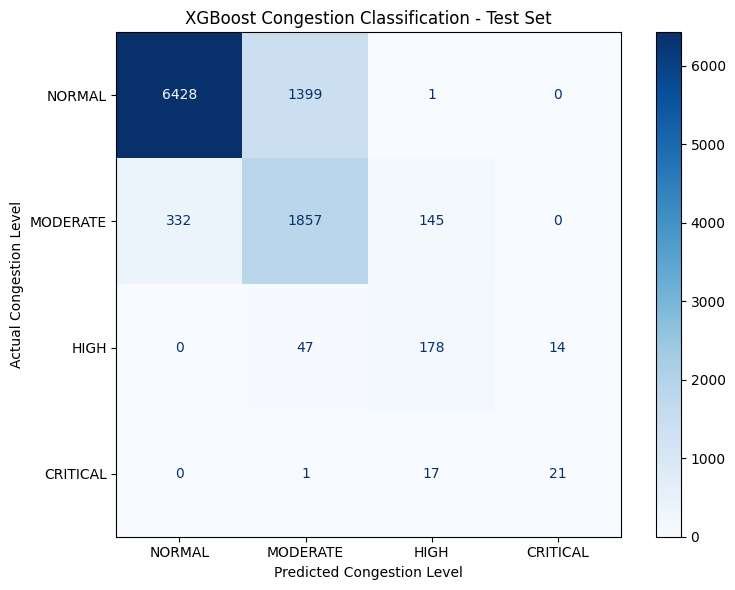

In [ ]:
# ============================================================
# 4.9 Confusion Matrix - XGBoost Congestion Classifier
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Define class order
congestion_class_order = [
    "NORMAL",
    "MODERATE",
    "HIGH",
    "CRITICAL"
]

# Calculate confusion matrix
cm = confusion_matrix(
    y_congestion_test,
    xgb_congestion_test_labels,
    labels=congestion_class_order
)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=congestion_class_order
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

ax.set_title("XGBoost Congestion Classification - Test Set")
ax.set_xlabel("Predicted Congestion Level")
ax.set_ylabel("Actual Congestion Level")

plt.tight_layout()
plt.show()

Top 15 features influencing congestion prediction:
                         feature  importance
          numeric__current_queue    0.184526
     categorical__centre_id_C004    0.126228
     numeric__centre_utilization    0.093945
       numeric__bookings_next_2h    0.030288
  numeric__arrival_service_ratio    0.029498
      numeric__completed_last_1h    0.028576
numeric__centre_capacity_farmers    0.024704
     categorical__centre_id_C003    0.022697
               numeric__hour_cos    0.020878
               numeric__hour_sin    0.018461
     categorical__centre_id_C015    0.017513
                   numeric__hour    0.016955
     categorical__centre_id_C026    0.016313
         categorical__crop_Paddy    0.014605
         numeric__weather_factor    0.014060


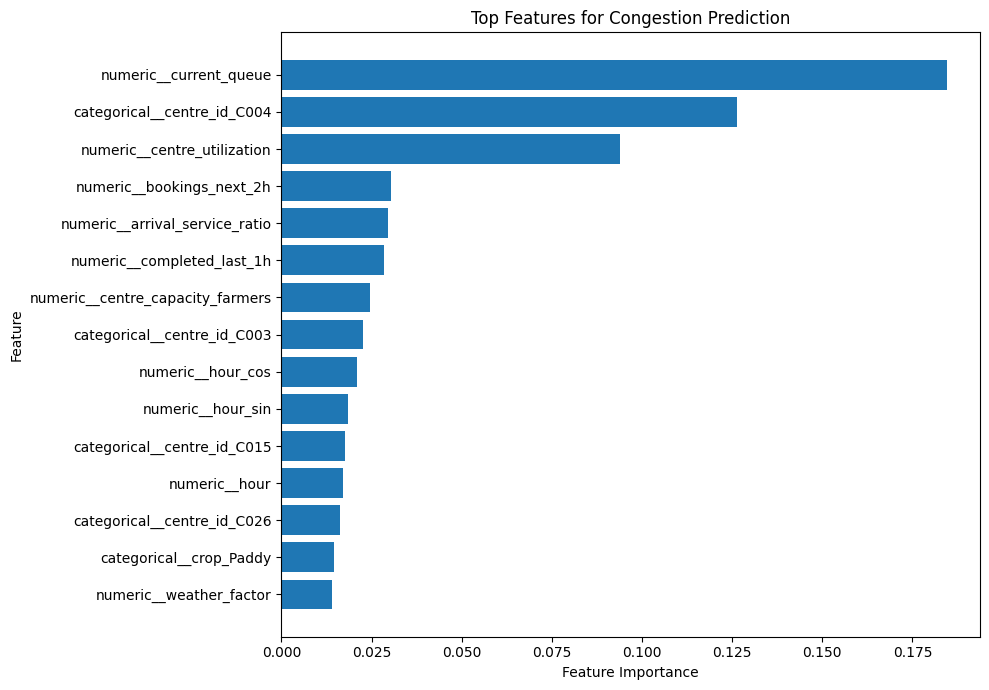

In [ ]:
# ============================================================
# 4.10 Feature Importance - XGBoost Congestion Classifier
# ============================================================

# Get the trained XGBoost model from the pipeline
congestion_xgb = xgb_congestion_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = (
    xgb_congestion_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get feature importance
importance_values = congestion_xgb.feature_importances_

# Create feature importance dataframe
congestion_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
})

# Sort by importance
congestion_importance_df = congestion_importance_df.sort_values(
    by="importance",
    ascending=False
)

# Display top 15 features
print("Top 15 features influencing congestion prediction:")
print(
    congestion_importance_df.head(15).to_string(index=False)
)

# Plot top 15 features
top_features = congestion_importance_df.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features for Congestion Prediction")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 5.1 Load Queue Forecasting Dataset
# ============================================================

queue_file = "/content/05_queue_forecasting_data.csv"

queue_df = pd.read_csv(queue_file)

print("Shape:", queue_df.shape)

print("\nColumns:")
print(queue_df.columns.tolist())

print("\nMissing values:")
print(queue_df.isna().sum().sum())

print("\nTarget summary:")
print(queue_df["future_queue_1h"].describe())

Shape: (64800, 22)

Columns:
['centre_id', 'date', 'hour', 'day_of_week', 'crop', 'weather_factor', 'current_queue', 'bookings_next_2h', 'arrivals_last_1h', 'completed_last_1h', 'active_counters', 'centre_capacity_farmers', 'hourly_capacity_farmers', 'historical_avg_queue', 'historical_avg_wait_min', 'quantity_total_kg', 'avg_processing_time_min', 'centre_utilization', 'arrival_service_ratio', 'hour_sin', 'hour_cos', 'future_queue_1h']

Missing values:
0

Target summary:
count    64800.000000
mean         7.217531
std          8.039551
min          0.000000
25%          0.000000
50%          5.000000
75%         11.000000
max         79.000000
Name: future_queue_1h, dtype: float64


In [ ]:
# ============================================================
# 5.2 Train / Validation / Test Split
# ============================================================

# Convert date to datetime
queue_df["date"] = pd.to_datetime(queue_df["date"])

# Chronological split
queue_train = queue_df[
    queue_df["date"] <= "2026-04-30"
].copy()

queue_val = queue_df[
    (queue_df["date"] >= "2026-05-01") &
    (queue_df["date"] <= "2026-05-31")
].copy()

queue_test = queue_df[
    queue_df["date"] >= "2026-06-01"
].copy()

print("Train shape:", queue_train.shape)
print("Validation shape:", queue_val.shape)
print("Test shape:", queue_test.shape)

print("\nTrain dates:",
      queue_train["date"].min().date(),
      "to",
      queue_train["date"].max().date())

print("Validation dates:",
      queue_val["date"].min().date(),
      "to",
      queue_val["date"].max().date())

print("Test dates:",
      queue_test["date"].min().date(),
      "to",
      queue_test["date"].max().date())

print("\nTarget means:")
print("Train:", round(queue_train["future_queue_1h"].mean(), 2))
print("Validation:", round(queue_val["future_queue_1h"].mean(), 2))
print("Test:", round(queue_test["future_queue_1h"].mean(), 2))

Train shape: (43200, 22)
Validation shape: (11160, 22)
Test shape: (10440, 22)

Train dates: 2026-01-01 to 2026-04-30
Validation dates: 2026-05-01 to 2026-05-31
Test dates: 2026-06-01 to 2026-06-29

Target means:
Train: 7.31
Validation: 7.26
Test: 6.77


In [ ]:
# ============================================================
# 5.3 Feature and Target Preparation
# ============================================================

# Target
queue_target = "future_queue_1h"

# Categorical features
queue_categorical_features = [
    "centre_id",
    "crop"
]

# Numerical features
queue_numeric_features = [
    "hour",
    "day_of_week",
    "weather_factor",
    "current_queue",
    "bookings_next_2h",
    "arrivals_last_1h",
    "completed_last_1h",
    "active_counters",
    "centre_capacity_farmers",
    "hourly_capacity_farmers",
    "historical_avg_queue",
    "historical_avg_wait_min",
    "quantity_total_kg",
    "avg_processing_time_min",
    "centre_utilization",
    "arrival_service_ratio",
    "hour_sin",
    "hour_cos"
]

# Combine features
queue_features = (
    queue_categorical_features +
    queue_numeric_features
)

# Create X and y
X_queue_train = queue_train[queue_features]
y_queue_train = queue_train[queue_target]

X_queue_val = queue_val[queue_features]
y_queue_val = queue_val[queue_target]

X_queue_test = queue_test[queue_features]
y_queue_test = queue_test[queue_target]

print("Number of features:", len(queue_features))

print("X_train:", X_queue_train.shape)
print("y_train:", y_queue_train.shape)

print("X_val:", X_queue_val.shape)
print("y_val:", y_queue_val.shape)

print("X_test:", X_queue_test.shape)
print("y_test:", y_queue_test.shape)

print("\nTarget statistics:")
print(y_queue_train.describe())

Number of features: 20
X_train: (43200, 20)
y_train: (43200,)
X_val: (11160, 20)
y_val: (11160,)
X_test: (10440, 20)
y_test: (10440,)

Target statistics:
count    43200.000000
mean         7.314375
std          8.160474
min          0.000000
25%          0.000000
50%          5.000000
75%         11.000000
max         79.000000
Name: future_queue_1h, dtype: float64


In [ ]:
# ============================================================
# 5.4 Queue Forecasting Preprocessing
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create preprocessing pipeline
queue_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            queue_categorical_features
        ),
        (
            "numeric",
            "passthrough",
            queue_numeric_features
        )
    ]
)

print("Queue forecasting preprocessing pipeline created successfully.")

Queue forecasting preprocessing pipeline created successfully.


In [ ]:
# ============================================================
# 5.5 Baseline Queue Forecasting
# ============================================================

def calculate_queue_baseline(data):
    """
    Simple queue forecast:
    current queue + recent arrivals - recent completions
    """

    predicted_queue = (
        data["current_queue"]
        + data["arrivals_last_1h"]
        - data["completed_last_1h"]
    )

    # Queue cannot be negative
    predicted_queue = predicted_queue.clip(lower=0)

    return predicted_queue


# Generate baseline predictions on the test set
queue_baseline_pred = calculate_queue_baseline(queue_test)

print("Baseline queue predictions created successfully.")

print("\nBaseline prediction statistics:")
print(queue_baseline_pred.describe())

Baseline queue predictions created successfully.

Baseline prediction statistics:
count    10440.000000
mean         3.040613
std          5.333308
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         57.000000
dtype: float64


In [ ]:

# ============================================================
# 5.6 Baseline Queue Forecast Evaluation
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate baseline metrics
queue_baseline_mae = mean_absolute_error(
    y_queue_test,
    queue_baseline_pred
)

queue_baseline_rmse = np.sqrt(
    mean_squared_error(
        y_queue_test,
        queue_baseline_pred
    )
)

queue_baseline_r2 = r2_score(
    y_queue_test,
    queue_baseline_pred
)

print("========== BASELINE QUEUE FORECAST ==========")
print("MAE :", round(queue_baseline_mae, 4))
print("RMSE:", round(queue_baseline_rmse, 4))
print("R²  :", round(queue_baseline_r2, 4))


========== BASELINE QUEUE FORECAST ==========
MAE : 4.2718
RMSE: 6.1636
R²  : 0.3267


In [ ]:
# ============================================================
# 5.7 Train XGBoost Queue Forecasting Model
# ============================================================

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

# Create XGBoost regression model
xgb_queue_model = Pipeline(
    steps=[
        (
            "preprocessor",
            queue_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
xgb_queue_model.fit(
    X_queue_train,
    y_queue_train
)

print("XGBoost queue forecasting model trained successfully.")

XGBoost queue forecasting model trained successfully.


In [ ]:
# ============================================================
# 5.8 Evaluate XGBoost Queue Forecasting Model
# ============================================================

# Generate predictions
queue_xgb_val_pred = xgb_queue_model.predict(
    X_queue_val
)

queue_xgb_test_pred = xgb_queue_model.predict(
    X_queue_test
)

# Calculate validation metrics
queue_val_mae = mean_absolute_error(
    y_queue_val,
    queue_xgb_val_pred
)

queue_val_rmse = np.sqrt(
    mean_squared_error(
        y_queue_val,
        queue_xgb_val_pred
    )
)

queue_val_r2 = r2_score(
    y_queue_val,
    queue_xgb_val_pred
)

# Calculate test metrics
queue_test_mae = mean_absolute_error(
    y_queue_test,
    queue_xgb_test_pred
)

queue_test_rmse = np.sqrt(
    mean_squared_error(
        y_queue_test,
        queue_xgb_test_pred
    )
)

queue_test_r2 = r2_score(
    y_queue_test,
    queue_xgb_test_pred
)

print("========== VALIDATION RESULTS ==========")
print("MAE :", round(queue_val_mae, 4))
print("RMSE:", round(queue_val_rmse, 4))
print("R²  :", round(queue_val_r2, 4))

print("\n========== TEST RESULTS ==========")
print("MAE :", round(queue_test_mae, 4))
print("RMSE:", round(queue_test_rmse, 4))
print("R²  :", round(queue_test_r2, 4))

# Compare against baseline
print("\n========== BASELINE vs XGBOOST ==========")
print("Baseline Test MAE :", round(queue_baseline_mae, 4))
print("XGBoost Test MAE  :", round(queue_test_mae, 4))

mae_improvement = (
    (queue_baseline_mae - queue_test_mae)
    / queue_baseline_mae
) * 100

print(
    "MAE Improvement    :",
    round(mae_improvement, 2),
    "%"
)

========== VALIDATION RESULTS ==========
MAE : 2.71
RMSE: 3.6071
R²  : 0.7983

========== TEST RESULTS ==========
MAE : 2.7184
RMSE: 3.5659
R²  : 0.7746

========== BASELINE vs XGBOOST ==========
Baseline Test MAE : 4.2718
XGBoost Test MAE  : 2.7184
MAE Improvement    : 36.36 %


Top 15 features influencing future queue:
                         feature  importance
          numeric__current_queue    0.471029
     numeric__centre_utilization    0.076023
      numeric__completed_last_1h    0.058905
       numeric__bookings_next_2h    0.051878
  numeric__arrival_service_ratio    0.042886
numeric__centre_capacity_farmers    0.033986
               numeric__hour_cos    0.030553
                   numeric__hour    0.017130
               numeric__hour_sin    0.015463
     categorical__centre_id_C018    0.014467
       numeric__arrivals_last_1h    0.012422
     categorical__centre_id_C005    0.008650
numeric__hourly_capacity_farmers    0.007892
     categorical__centre_id_C013    0.007561
     categorical__centre_id_C015    0.006996


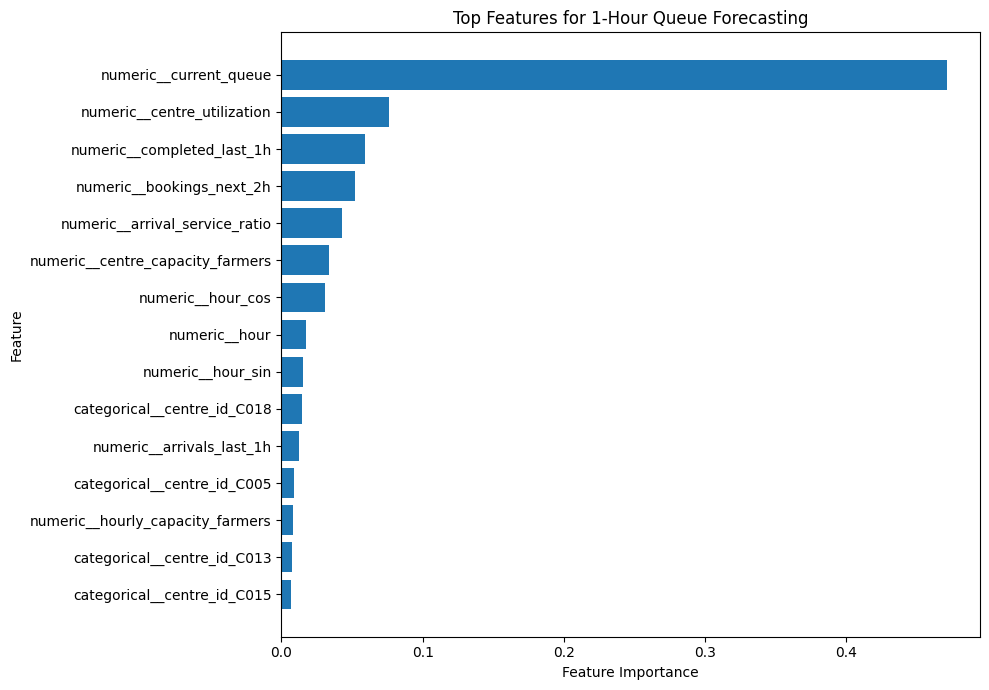

In [ ]:
# ============================================================
# 5.9 Feature Importance - Queue Forecasting
# ============================================================

# Get trained XGBoost model
queue_xgb = xgb_queue_model.named_steps["model"]

# Get feature names after preprocessing
queue_feature_names = (
    xgb_queue_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get feature importance values
queue_importance_values = queue_xgb.feature_importances_

# Create dataframe
queue_importance_df = pd.DataFrame({
    "feature": queue_feature_names,
    "importance": queue_importance_values
})

# Sort by importance
queue_importance_df = queue_importance_df.sort_values(
    by="importance",
    ascending=False
)

# Display top 15 features
print("Top 15 features influencing future queue:")
print(
    queue_importance_df.head(15).to_string(index=False)
)

# Plot top 15 features
top_queue_features = queue_importance_df.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_queue_features["feature"],
    top_queue_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features for 1-Hour Queue Forecasting")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 6.1 Load Centre & Slot Recommendation Scenarios
# ============================================================

recommendation_file = (
    "/content/08_centre_slot_recommendation_scenarios.csv"
)

recommendation_df = pd.read_csv(recommendation_file)

print("Shape:", recommendation_df.shape)

print("\nColumns:")
print(recommendation_df.columns.tolist())

print("\nMissing values:")
print(recommendation_df.isna().sum().sum())

print("\nNumber of scenarios:",
      recommendation_df["scenario_id"].nunique())

print("\nCandidate centres per scenario:")
print(
    recommendation_df.groupby("scenario_id")
    .size()
    .value_counts()
    .sort_index()
)

Shape: (20000, 10)

Columns:
['scenario_id', 'farmer_id', 'candidate_rank', 'centre_id', 'preferred_hour', 'distance_km', 'predicted_wait_min', 'slot_capacity_remaining', 'predicted_future_queue', 'centre_utilization']

Missing values:
0

Number of scenarios: 5000

Candidate centres per scenario:
4    5000
Name: count, dtype: int64


In [ ]:
# ============================================================
# 6.2 Smart Centre & Slot Recommendation — Scoring Engine
# ============================================================

# Lower score = better recommendation

def normalize_series(series):
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series(0.0, index=series.index)

    return (series - min_val) / (max_val - min_val)


recommendation_scored = recommendation_df.copy()

# Normalize each factor within each farmer scenario
grouped = recommendation_scored.groupby("scenario_id")

recommendation_scored["wait_score"] = grouped[
    "predicted_wait_min"
].transform(normalize_series)

recommendation_scored["distance_score"] = grouped[
    "distance_km"
].transform(normalize_series)

recommendation_scored["future_queue_score"] = grouped[
    "predicted_future_queue"
].transform(normalize_series)

# More remaining slot capacity = better
recommendation_scored["slot_capacity_score"] = 1 - grouped[
    "slot_capacity_remaining"
].transform(normalize_series)

# Final decision score
recommendation_scored["recommendation_score"] = (
    0.35 * recommendation_scored["wait_score"]
    + 0.25 * recommendation_scored["distance_score"]
    + 0.20 * recommendation_scored["future_queue_score"]
    + 0.20 * recommendation_scored["slot_capacity_score"]
)

# Rank candidates: 1 = best
recommendation_scored["ai_rank"] = (
    recommendation_scored
    .groupby("scenario_id")["recommendation_score"]
    .rank(method="first", ascending=True)
    .astype(int)
)

print("Scoring completed.")
print("Total candidate records:", len(recommendation_scored))
print("Scenarios:", recommendation_scored["scenario_id"].nunique())

print("\nAI rank distribution:")
print(recommendation_scored["ai_rank"].value_counts().sort_index())

print("\nExample scenario:")
print(
    recommendation_scored[
        recommendation_scored["scenario_id"] == 1
    ][[
        "scenario_id",
        "centre_id",
        "preferred_hour",
        "distance_km",
        "predicted_wait_min",
        "slot_capacity_remaining",
        "predicted_future_queue",
        "centre_utilization",
        "recommendation_score",
        "ai_rank"
    ]].sort_values("ai_rank")
)

Scoring completed.
Total candidate records: 20000
Scenarios: 5000

AI rank distribution:
ai_rank
1    5000
2    5000
3    5000
4    5000
Name: count, dtype: int64

Example scenario:
Empty DataFrame
Columns: [scenario_id, centre_id, preferred_hour, distance_km, predicted_wait_min, slot_capacity_remaining, predicted_future_queue, centre_utilization, recommendation_score, ai_rank]
Index: []


In [ ]:
# ============================================================
# 6.3 Inspect Scenario IDs & AI Recommendations
# ============================================================

print("First 10 scenario IDs:")
print(recommendation_scored["scenario_id"].unique()[:10])

# Select the first actual scenario instead of assuming scenario_id = 1
first_scenario = recommendation_scored["scenario_id"].iloc[0]

print("\nSelected scenario:", first_scenario)

example_recommendation = (
    recommendation_scored[
        recommendation_scored["scenario_id"] == first_scenario
    ][[
        "scenario_id",
        "centre_id",
        "preferred_hour",
        "distance_km",
        "predicted_wait_min",
        "slot_capacity_remaining",
        "predicted_future_queue",
        "centre_utilization",
        "recommendation_score",
        "ai_rank"
    ]]
    .sort_values("ai_rank")
)

print("\nCandidate centres ranked by AI:")
print(example_recommendation.to_string(index=False))

print("\nRecommended centre:")
print(
    example_recommendation[
        example_recommendation["ai_rank"] == 1
    ].to_string(index=False)
)

First 10 scenario IDs:
['S000001' 'S000002' 'S000003' 'S000004' 'S000005' 'S000006' 'S000007'
 'S000008' 'S000009' 'S000010']

Selected scenario: S000001

Candidate centres ranked by AI:
scenario_id centre_id  preferred_hour  distance_km  predicted_wait_min  slot_capacity_remaining  predicted_future_queue  centre_utilization  recommendation_score  ai_rank
    S000001      C005              12         9.28               34.53                       13                      10               0.122              0.178577        1
    S000001      C014              12         8.89                6.48                        1                       3               0.082              0.247692        2
    S000001      C020              12        32.73               17.75                       13                       7               0.119              0.309174        3
    S000001      C004              12         3.27              127.82                        1                      33          

In [ ]:
# ============================================================
# 6.4 AI Recommendation vs Nearest-Centre Baseline
# ============================================================

# Baseline: always choose the nearest candidate centre
nearest_baseline = (
    recommendation_scored
    .sort_values(["scenario_id", "distance_km"])
    .groupby("scenario_id")
    .first()
    .reset_index()
)

# AI recommendation: rank = 1
ai_recommendation = (
    recommendation_scored[
        recommendation_scored["ai_rank"] == 1
    ]
    .copy()
)

# Compare the two choices
comparison = ai_recommendation[[
    "scenario_id",
    "centre_id",
    "preferred_hour",
    "distance_km",
    "predicted_wait_min",
    "predicted_future_queue",
    "slot_capacity_remaining",
    "centre_utilization"
]].rename(columns={
    "centre_id": "ai_centre",
    "distance_km": "ai_distance_km",
    "predicted_wait_min": "ai_wait_min",
    "predicted_future_queue": "ai_future_queue",
    "slot_capacity_remaining": "ai_slot_capacity",
    "centre_utilization": "ai_utilization"
})

comparison = comparison.merge(
    nearest_baseline[[
        "scenario_id",
        "centre_id",
        "distance_km",
        "predicted_wait_min",
        "predicted_future_queue",
        "slot_capacity_remaining",
        "centre_utilization"
    ]].rename(columns={
        "centre_id": "nearest_centre",
        "distance_km": "nearest_distance_km",
        "predicted_wait_min": "nearest_wait_min",
        "predicted_future_queue": "nearest_future_queue",
        "slot_capacity_remaining": "nearest_slot_capacity",
        "centre_utilization": "nearest_utilization"
    }),
    on="scenario_id"
)

# Whether AI selected a different centre
comparison["centre_changed"] = (
    comparison["ai_centre"] != comparison["nearest_centre"]
)

# Calculate differences
comparison["wait_reduction_min"] = (
    comparison["nearest_wait_min"] -
    comparison["ai_wait_min"]
)

comparison["queue_reduction"] = (
    comparison["nearest_future_queue"] -
    comparison["ai_future_queue"]
)

comparison["distance_extra_km"] = (
    comparison["ai_distance_km"] -
    comparison["nearest_distance_km"]
)

print("Total scenarios:", len(comparison))

print("\nCentre changed by AI:")
print(comparison["centre_changed"].value_counts())

print("\nAverage predicted waiting time:")
print(
    "Nearest-centre baseline:",
    round(comparison["nearest_wait_min"].mean(), 2), "min"
)
print(
    "AI recommendation:",
    round(comparison["ai_wait_min"].mean(), 2), "min"
)

print("\nAverage predicted future queue:")
print(
    "Nearest-centre baseline:",
    round(comparison["nearest_future_queue"].mean(), 2)
)
print(
    "AI recommendation:",
    round(comparison["ai_future_queue"].mean(), 2)
)

print("\nAverage distance:")
print(
    "Nearest-centre baseline:",
    round(comparison["nearest_distance_km"].mean(), 2), "km"
)
print(
    "AI recommendation:",
    round(comparison["ai_distance_km"].mean(), 2), "km"
)

print("\nAverage predicted waiting-time reduction:",
      round(comparison["wait_reduction_min"].mean(), 2), "min")

print("Average future-queue reduction:",
      round(comparison["queue_reduction"].mean(), 2), "farmers")

print("Average additional distance:",
      round(comparison["distance_extra_km"].mean(), 2), "km")

Total scenarios: 5000

Centre changed by AI:
centre_changed
True     2696
False    2304
Name: count, dtype: int64

Average predicted waiting time:
Nearest-centre baseline: 15.82 min
AI recommendation: 9.02 min

Average predicted future queue:
Nearest-centre baseline: 5.77
AI recommendation: 4.14

Average distance:
Nearest-centre baseline: 9.64 km
AI recommendation: 15.66 km

Average predicted waiting-time reduction: 6.8 min
Average future-queue reduction: 1.63 farmers
Average additional distance: 6.02 km


In [ ]:
# ============================================================
# 6.5 Smart Recommendation Function
# ============================================================

def recommend_centre_and_slot(
    scenario_id,
    recommendation_data=recommendation_scored
):
    """
    Return the best centre + slot for a given farmer scenario.
    Lower recommendation score = better choice.
    """

    candidates = recommendation_data[
        recommendation_data["scenario_id"] == scenario_id
    ].copy()

    if candidates.empty:
        return None

    best = candidates.loc[
        candidates["recommendation_score"].idxmin()
    ]

    return {
        "scenario_id": best["scenario_id"],
        "recommended_centre": best["centre_id"],
        "recommended_hour": int(best["preferred_hour"]),
        "predicted_wait_min": round(
            float(best["predicted_wait_min"]), 2
        ),
        "predicted_future_queue": round(
            float(best["predicted_future_queue"]), 2
        ),
        "distance_km": round(
            float(best["distance_km"]), 2
        ),
        "slot_capacity_remaining": int(
            best["slot_capacity_remaining"]
        ),
        "centre_utilization": round(
            float(best["centre_utilization"]), 3
        ),
        "recommendation_score": round(
            float(best["recommendation_score"]), 4
        )
    }


# Test the recommendation function
test_scenario = recommendation_scored["scenario_id"].iloc[0]

result = recommend_centre_and_slot(test_scenario)

print("Smart Recommendation:")
print(result)

Smart Recommendation:
{'scenario_id': 'S000001', 'recommended_centre': 'C005', 'recommended_hour': 12, 'predicted_wait_min': 34.53, 'predicted_future_queue': 10.0, 'distance_km': 9.28, 'slot_capacity_remaining': 13, 'centre_utilization': 0.122, 'recommendation_score': 0.1786}


In [ ]:
# ============================================================
# 7.1 Integrated AI Decision Pipeline
# ============================================================

def integrated_ai_decision(
    centre_id,
    hour,
    day_of_week,
    crop,
    weather_factor,
    current_queue,
    bookings_next_2h,
    arrivals_last_1h,
    completed_last_1h,
    active_counters,
    centre_capacity_farmers,
    hourly_capacity_farmers,
    historical_avg_queue,
    historical_avg_wait_min,
    quantity_total_kg,
    avg_quantity_per_farmer_kg,
    avg_processing_time_min,
    centre_utilization,
    arrival_service_ratio,
    hour_sin,
    hour_cos
):
    """
    Integrated AI pipeline:

    1. Predict waiting time
    2. Forecast future queue
    3. Predict congestion level
    """

    input_data = pd.DataFrame([{
        "centre_id": centre_id,
        "hour": hour,
        "day_of_week": day_of_week,
        "crop": crop,
        "weather_factor": weather_factor,
        "current_queue": current_queue,
        "bookings_next_2h": bookings_next_2h,
        "arrivals_last_1h": arrivals_last_1h,
        "completed_last_1h": completed_last_1h,
        "active_counters": active_counters,
        "centre_capacity_farmers": centre_capacity_farmers,
        "hourly_capacity_farmers": hourly_capacity_farmers,
        "historical_avg_queue": historical_avg_queue,
        "historical_avg_wait_min": historical_avg_wait_min,
        "quantity_total_kg": quantity_total_kg,
        "avg_quantity_per_farmer_kg": avg_quantity_per_farmer_kg,
        "avg_processing_time_min": avg_processing_time_min,
        "centre_utilization": centre_utilization,
        "arrival_service_ratio": arrival_service_ratio,
        "hour_sin": hour_sin,
        "hour_cos": hour_cos
    }])

    # --------------------------------------------------------
    # 1. Waiting-time prediction
    # --------------------------------------------------------
    predicted_wait = float(
        xgb_model.predict(input_data)[0]
    )

    # --------------------------------------------------------
    # 2. Future queue forecasting
    # --------------------------------------------------------
    predicted_future_queue = float(
        xgb_queue_model.predict(input_data)[0]
    )

    # --------------------------------------------------------
    # 3. Congestion prediction
    # --------------------------------------------------------
    congestion_encoded = xgb_congestion_model.predict(
        input_data
    )[0]

    congestion_level = (
        congestion_label_encoder
        .inverse_transform([int(congestion_encoded)])[0]
    )

    return {
        "predicted_wait_min": round(predicted_wait, 2),
        "predicted_future_queue": round(
            max(predicted_future_queue, 0), 2
        ),
        "predicted_congestion": congestion_level
    }


# ------------------------------------------------------------
# Test the integrated pipeline using one real test record
# ------------------------------------------------------------

test_row = test_df.iloc[0]

pipeline_result = integrated_ai_decision(
    centre_id=test_row["centre_id"],
    hour=test_row["hour"],
    day_of_week=test_row["day_of_week"],
    crop=test_row["crop"],
    weather_factor=test_row["weather_factor"],
    current_queue=test_row["current_queue"],
    bookings_next_2h=test_row["bookings_next_2h"],
    arrivals_last_1h=test_row["arrivals_last_1h"],
    completed_last_1h=test_row["completed_last_1h"],
    active_counters=test_row["active_counters"],
    centre_capacity_farmers=test_row["centre_capacity_farmers"],
    hourly_capacity_farmers=test_row["hourly_capacity_farmers"],
    historical_avg_queue=test_row["historical_avg_queue"],
    historical_avg_wait_min=test_row["historical_avg_wait_min"],
    quantity_total_kg=test_row["quantity_total_kg"],
    avg_quantity_per_farmer_kg=test_row["avg_quantity_per_farmer_kg"],
    avg_processing_time_min=test_row["avg_processing_time_min"],
    centre_utilization=test_row["centre_utilization"],
    arrival_service_ratio=test_row["arrival_service_ratio"],
    hour_sin=test_row["hour_sin"],
    hour_cos=test_row["hour_cos"]
)

print("Integrated AI Decision:")
print(pipeline_result)

Integrated AI Decision:
{'predicted_wait_min': 15.63, 'predicted_future_queue': 9.46, 'predicted_congestion': 'MODERATE'}


In [ ]:
# ============================================================
# 7.2 System Impact Metrics
# ============================================================

total_scenarios = len(comparison)

ai_wait = comparison["ai_wait_min"].mean()
baseline_wait = comparison["nearest_wait_min"].mean()

ai_queue = comparison["ai_future_queue"].mean()
baseline_queue = comparison["nearest_future_queue"].mean()

redirection_rate = (
    comparison["centre_changed"].mean() * 100
)

wait_reduction = baseline_wait - ai_wait
queue_reduction = baseline_queue - ai_queue

wait_reduction_pct = (
    wait_reduction / baseline_wait * 100
)

queue_reduction_pct = (
    queue_reduction / baseline_queue * 100
)

additional_distance = comparison[
    "distance_extra_km"
].mean()

print("============================================================")
print("SMART PROCUREMENT SYSTEM — SIMULATED IMPACT")
print("============================================================")

print(f"\nScenarios evaluated: {total_scenarios:,}")

print("\nAverage predicted waiting time:")
print(f"  Baseline : {baseline_wait:.2f} min")
print(f"  AI       : {ai_wait:.2f} min")
print(f"  Reduction: {wait_reduction:.2f} min ({wait_reduction_pct:.2f}%)")

print("\nAverage predicted future queue:")
print(f"  Baseline : {baseline_queue:.2f} farmers")
print(f"  AI       : {ai_queue:.2f} farmers")
print(f"  Reduction: {queue_reduction:.2f} farmers ({queue_reduction_pct:.2f}%)")

print("\nCentre redirection:")
print(f"  {redirection_rate:.2f}% of scenarios chose a different centre")

print("\nAverage additional travel distance:")
print(f"  {additional_distance:.2f} km")

print("\n============================================================")
print("NOTE: Results are from synthetic scenario simulation.")
print("They are NOT real-world government-centre performance.")
print("============================================================")

SMART PROCUREMENT SYSTEM — SIMULATED IMPACT

Scenarios evaluated: 5,000

Average predicted waiting time:
  Baseline : 15.82 min
  AI       : 9.02 min
  Reduction: 6.80 min (42.98%)

Average predicted future queue:
  Baseline : 5.77 farmers
  AI       : 4.14 farmers
  Reduction: 1.63 farmers (28.22%)

Centre redirection:
  53.92% of scenarios chose a different centre

Average additional travel distance:
  6.02 km

NOTE: Results are from synthetic scenario simulation.
They are NOT real-world government-centre performance.


In [ ]:
# ============================================================
# 8.1 Save Trained AI/ML Models
# ============================================================

import joblib
import os

model_dir = "/content/SIH26032_models"
os.makedirs(model_dir, exist_ok=True)

# Save waiting-time model
joblib.dump(
    xgb_model,
    f"{model_dir}/waiting_time_xgb.pkl"
)

# Save queue forecasting model
joblib.dump(
    xgb_queue_model,
    f"{model_dir}/queue_forecasting_xgb.pkl"
)

# Save congestion classification model
joblib.dump(
    xgb_congestion_model,
    f"{model_dir}/congestion_xgb.pkl"
)

# Save congestion label encoder
joblib.dump(
    congestion_label_encoder,
    f"{model_dir}/congestion_label_encoder.pkl"
)

print("Models saved successfully.")

print("\nSaved files:")
for file_name in sorted(os.listdir(model_dir)):
    file_path = os.path.join(model_dir, file_name)
    size_kb = os.path.getsize(file_path) / 1024
    print(f"  {file_name} — {size_kb:.1f} KB")

Models saved successfully.

Saved files:
  congestion_label_encoder.pkl — 0.5 KB
  congestion_xgb.pkl — 3879.3 KB
  queue_forecasting_xgb.pkl — 1359.3 KB
  waiting_time_xgb.pkl — 1308.2 KB


In [ ]:
# ============================================================
# 8.2 Verify Saved Models
# ============================================================

import joblib
import os

# Load saved models
loaded_waiting_model = joblib.load(
    "/content/SIH26032_models/waiting_time_xgb.pkl"
)

loaded_queue_model = joblib.load(
    "/content/SIH26032_models/queue_forecasting_xgb.pkl"
)

loaded_congestion_model = joblib.load(
    "/content/SIH26032_models/congestion_xgb.pkl"
)

loaded_label_encoder = joblib.load(
    "/content/SIH26032_models/congestion_label_encoder.pkl"
)

# Use the same test record used earlier
verification_row = test_df.iloc[0]

verification_input = pd.DataFrame([{
    "centre_id": verification_row["centre_id"],
    "hour": verification_row["hour"],
    "day_of_week": verification_row["day_of_week"],
    "crop": verification_row["crop"],
    "weather_factor": verification_row["weather_factor"],
    "current_queue": verification_row["current_queue"],
    "bookings_next_2h": verification_row["bookings_next_2h"],
    "arrivals_last_1h": verification_row["arrivals_last_1h"],
    "completed_last_1h": verification_row["completed_last_1h"],
    "active_counters": verification_row["active_counters"],
    "centre_capacity_farmers": verification_row["centre_capacity_farmers"],
    "hourly_capacity_farmers": verification_row["hourly_capacity_farmers"],
    "historical_avg_queue": verification_row["historical_avg_queue"],
    "historical_avg_wait_min": verification_row["historical_avg_wait_min"],
    "quantity_total_kg": verification_row["quantity_total_kg"],
    "avg_quantity_per_farmer_kg": verification_row["avg_quantity_per_farmer_kg"],
    "avg_processing_time_min": verification_row["avg_processing_time_min"],
    "centre_utilization": verification_row["centre_utilization"],
    "arrival_service_ratio": verification_row["arrival_service_ratio"],
    "hour_sin": verification_row["hour_sin"],
    "hour_cos": verification_row["hour_cos"]
}])

# Predictions from saved models
saved_wait_prediction = float(
    loaded_waiting_model.predict(verification_input)[0]
)

saved_queue_prediction = float(
    loaded_queue_model.predict(verification_input)[0]
)

saved_congestion_encoded = loaded_congestion_model.predict(
    verification_input
)[0]

saved_congestion_prediction = loaded_label_encoder.inverse_transform(
    [int(saved_congestion_encoded)]
)[0]

print("============================================================")
print("SAVED MODEL VERIFICATION")
print("============================================================")

print(f"Waiting-time prediction : {saved_wait_prediction:.2f} min")
print(f"Future queue prediction : {saved_queue_prediction:.2f} farmers")
print(f"Congestion prediction   : {saved_congestion_prediction}")

print("\nModel files successfully loaded and executed.")

print("\n============================================================")

SAVED MODEL VERIFICATION
Waiting-time prediction : 15.63 min
Future queue prediction : 9.46 farmers
Congestion prediction   : MODERATE

Model files successfully loaded and executed.

